In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk


In [36]:
data = pd.read_csv(r'D:\Project - Data Mining\Project\Data-Mining---Predictive-Maintenance-of-CNC-Machines\Local Repository\Data-Mining---Predictive-Maintenance-of-CNC-Machines\Pre-processing\Tool-Wear-forces\final_data_fx.csv')
data.head(5)

,Position,TCond,vc,cat,cont_1,cont_2,Fx
0,131.404546,135.544571,132.075,-124.286899,-29.701906,0.432755,49.23
1,131.404546,135.544571,132.075,-124.286899,-29.714511,0.091866,49.23
2,131.404546,135.544571,132.075,-124.286899,-29.698246,0.455781,49.23
3,131.404546,135.544571,132.075,-124.286899,-29.692069,0.532965,49.23
4,131.404546,135.544571,132.075,-124.286899,-29.712496,1.058478,49.23


In [37]:
X = data.iloc[:,0:6]
y = data.iloc[:,-1:7]

In [38]:
X

,Position,TCond,vc,cat,cont_1,cont_2
0,131.404546,135.544571,132.075,-124.286899,-29.701906,0.432755
1,131.404546,135.544571,132.075,-124.286899,-29.714511,0.091866
2,131.404546,135.544571,132.075,-124.286899,-29.698246,0.455781
3,131.404546,135.544571,132.075,-124.286899,-29.692069,0.532965
4,131.404546,135.544571,132.075,-124.286899,-29.712496,1.058478
...,...,...,...,...,...,...
607,136.794167,156.606875,132.075,81.005487,-17.220510,2.885314
608,136.794167,156.606875,132.075,81.005487,-17.204441,3.266256
609,136.794167,156.606875,132.075,81.005487,-17.218978,3.665430
610,136.794167,156.606875,132.075,81.005487,-17.217630,2.459472


In [39]:
y

,Fx
0,49.23
1,49.23
2,49.23
3,49.23
4,49.23
...,...
607,195.10
608,195.10
609,195.10
610,195.10


In [40]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.25, random_state = 42)
# Train => 60%, Test => 20%, Validation => 20%

In [41]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Create a pipeline: StandardScaler + SVR
model = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=100, epsilon=0.1))

# Fit on training data
model.fit(X_train, y_train)

# Predict on validation or test data
y_pred = model.predict(X_val)


C:\Users\Lenovo-Pc\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


In [42]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
mse

11.976118438216641

In [43]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mse

9.662977378953359

In [44]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.9970397671819149

In [45]:
y_train = y_train.values.ravel() 
y_test = y_test.values.ravel() 
y_val = y_val.values.ravel() 

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)


y_train_pred = y_train_pred.ravel()
y_val_pred = y_val_pred.ravel()
y_test_pred = y_test_pred.ravel()


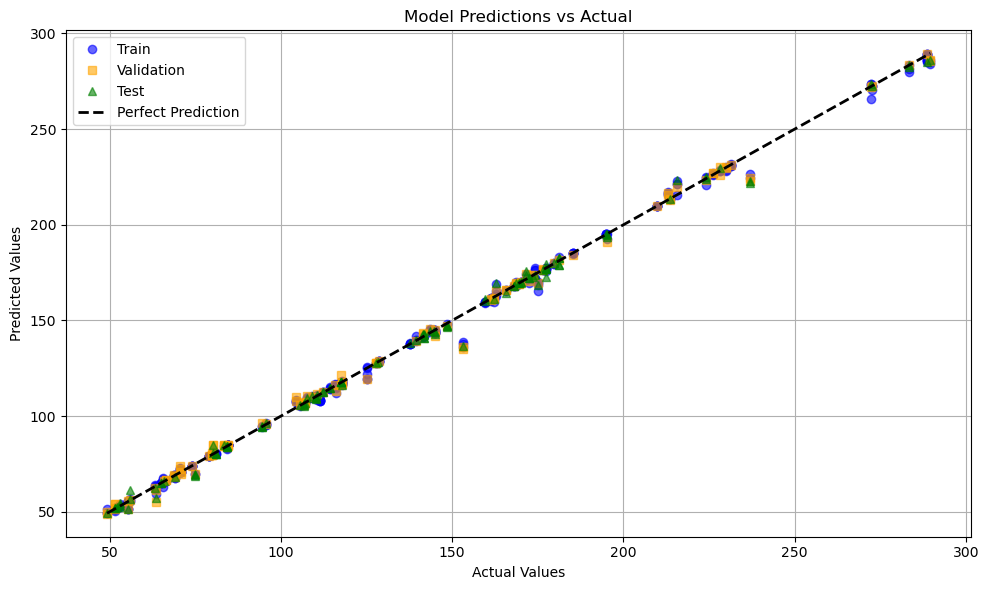

In [46]:
plt.figure(figsize=(10, 6))

plt.plot(y_train, y_train_pred, 'o', label='Train', color='blue', alpha=0.6)
plt.plot(y_val, y_val_pred, 's', label='Validation', color='orange', alpha=0.6)
plt.plot(y_test, y_test_pred, '^', label='Test', color='green', alpha=0.6)

# Reference perfect prediction line
min_val = min(y_train.min(), y_val.min(), y_test.min())
max_val = max(y_train.max(), y_val.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Model Predictions vs Actual')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
